In [47]:
import os 
import operator 

from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END


In [48]:
load_dotenv()

model = init_chat_model(model='gemini-2.5-flash-lite', api_key=os.getenv("GEMINI_API_KEY"), model_provider="google_genai")

In [49]:
class EvaluationSchema(BaseModel):
    feedback: str = Field(description="Detail feedback for this resume")
    score: int = Field(description="score out of 10", ge=0, le=10)

In [50]:
resume = """
MOSTAFA RAYHAN
Software Engineer
Web Developer with 3+ years of experience in designing and developing user interfaces, testing, and, debugging.
Proven ability in optimizing web functionalities that improve data retrieval and workflow efficiencies.
FiNTECH HUB Ltd (Development Engineering)
Mirpur 10, Dhaka, Bangladesh | July 2024 - Present
Working on a General Banking Solution, Core Banking Solution,
Security Module, and Administration Module using ASP.NET 8,
BLAZOR, and Oracle DB (Store Procedure).
Collaborate with cross-functional teams to implement solutions
Collaborated on full-stack development for the solutions
Optimize application architecture for improved performance,
integrating new technologies and best practices
Engaged actively in sprint planning, backlog grooming, and daily
stand-up meetings to ensure smooth project execution and
team alignment.
LEADS Corporation Limited (Banking Solutions)
Mirpur 14, Dhaka, Bangladesh | April 2024 - June 2024
The experienced developer is proficient in ASP.NET Core 6, Vue.js,
and Oracle DB (Store Procedure) and has a track record of
delivering robust banking software.
Successfully deployed the nCore365 Agent Banking Solution
across 8 live banks.
Working with nCore365 Agent Bank Solution on Agent Module
and Bank Module as a part of team.
Actively participated in sprint planning, backlog grooming, and
daily stand-up meetings
PharmAid-Rx
Gulshan-2, Dhaka, Bangladesh | March 2023 - December 2023
Software design, development, and maintenance using the latest
technologies such as React.js, Angular.js, Node.js, and Django.
Wrote clean, maintainable code and conducted rigorous testing
to ensure product reliability.
Committed to continuous learning, analysis, and implementation
of emerging technologies.
B.Sc. in Computer Science and Engineering
April 2019 – June 2023
CGPA: 3.56
Programming Skills: C#, Python,
JavaScript, TypeScript, C, C++
Web Technologies: .NET 8, .NET Web
API, .NET Core, Blazor, Angular, React,
Next.js, Vue3, Vuetify, Django, Django
REST Framework, Node.js, HTML5, CSS3,
Bootstrap5, Tailwind, Material UI,
jQuery.
Database: Oracle, MySQL, SQLite3,
MongoDB
Version Control: Git, GitHub, Microsoft
Azure
CI/CD : Microsoft Azure DevOps
Tools & IDE: Visual Studio 2022, Visual
Studio Code, PyCharm, Xampp, PL/SQL,
IIS, SQL Server, Figma
Achieved with a team the runner-up
position in the Code Generator
Application Contest organized by Fintech
Hub Ltd.
Successfully contributed to the
deployment of the nCore365 Agent
Banking Solution across 8 banks while at
Leads Corporation.
Junior Software Engineer
Junior Software Engineer
Software Developer
Daffodil International University
LANGUAGE
Bangla - Native
English - Fluent

"""

In [51]:
structured_output = model.with_structured_output(EvaluationSchema)

prompt = f'Evalute the resume and score the resume out of 10. here is the resume -{resume}'

result = structured_output.invoke(prompt)

In [52]:
from IPython.display import Markdown

Markdown(result.feedback)

The resume is well-structured and highlights relevant experience in software engineering and web development. It clearly outlines the candidate's responsibilities and achievements in various roles, utilizing technologies like ASP.NET, Blazor, React, and Node.js. The inclusion of specific projects like the nCore365 Agent Banking Solution and academic achievements adds credibility. The candidate demonstrates a good range of programming skills and familiarity with modern development tools and practices. However, quantifying achievements further (e.g., 'improved data retrieval by X%') could strengthen the impact.

In [53]:
print("Score of this resume out of 10 is: ",result.score)

Score of this resume out of 10 is:  7


In [54]:
class ResumeState(TypedDict):

    resume: str
    quality_feedback: str
    experience_feedback: str 
    programming_skill: str 
    overall_feedback: str
    individual_scores: Annotated[list[int], operator.add]
    avg_score: float
    response: str

### Define nodes

In [55]:
def quality_evaluation(state: ResumeState):
    prompt = f'Evaluate the resume quality for most talent senior software engineer candidate and provide a feedback and assign a score out of 10 \n {state['resume']}'

    output = structured_output.invoke(prompt)
    
    return {'quality_feedback':output.feedback, 'individual_scores': [output.score]}

In [56]:
def experience_evaluation(state: ResumeState):
    prompt = f'Evaluate the resume job experience for most talent senior software engineer candidate and provide a feedback and assign a score out of 10 \n {state['resume']}'

    output = structured_output.invoke(prompt)
    
    return {'experience_feedback':output.feedback, 'individual_scores': [output.score]}

In [57]:
def programming_skill_evaluation(state: ResumeState):
    prompt = f'Evaluate the resume programming skills and frameworks for most talent senior software engineer candidate and provide a feedback and assign a score out of 10 \n {state['resume']}'

    output = structured_output.invoke(prompt)
    print(output)
    
    return {'programming_skill':output.feedback, 'individual_scores': [output.score]}

In [58]:
def final_evaluation(state: ResumeState):
    prompt=f'''
    Based on the following feedbacks create a summarized feedback \n
    quality_feedback: {state['quality_feedback']}
    experience_feedback: {state['experience_feedback']}
    programming_skill_feedback: {state['programming_skill']}
    '''
    overall_feedback = model.invoke(prompt).content


    # avg score
    scores = state["individual_scores"]
    avg_score = sum(scores) / len(scores) if scores else 0.0

    return {'overall_feedback':overall_feedback, 'avg_score':avg_score}



In [59]:
def check_condition(state: ResumeState):
    if state['avg_score'] > 8.0: return 'positive_feedback'
    else : return 'negative_feedback'

In [60]:
def positive_feedback(state: ResumeState):
    prompt = f'For this resume -{state['resume']} give some positive feedback in a list'
    feedback = model.invoke(prompt).content
    return {'response':feedback}


def negative_feedback(state: ResumeState):
    prompt = f'For this resuem -{state['resume']} Give negative feedback(i mean where should imporve, what to have good for him etc in a list)'
    feedback = model.invoke(prompt).content
    return {'response':feedback}


### Graph initialization

In [61]:
graph = StateGraph(ResumeState)

## adding node
graph.add_node('quality_evaluation', quality_evaluation)
graph.add_node('experience_evaluation', experience_evaluation)
graph.add_node('programming_skill_evaluation', programming_skill_evaluation)
graph.add_node('final_evaluation', final_evaluation)
graph.add_node('positive_feedback', positive_feedback)
graph.add_node('negative_feedback', negative_feedback)

## adding edges
graph.add_edge(START, 'quality_evaluation')
graph.add_edge(START, 'experience_evaluation')
graph.add_edge(START, 'programming_skill_evaluation')

graph.add_edge('quality_evaluation', 'final_evaluation')
graph.add_edge('experience_evaluation', 'final_evaluation')
graph.add_edge('programming_skill_evaluation', 'final_evaluation')

# graph.add_conditional_edges('final_evaluation', check_condition)
graph.add_conditional_edges(
    'final_evaluation', 
    check_condition,
    {
        'positive_feedback': 'positive_feedback',
        'negative_feedback': 'negative_feedback'
    }
)

graph.add_edge('positive_feedback', END)
graph.add_edge('negative_feedback', END)

workflow = graph.compile()

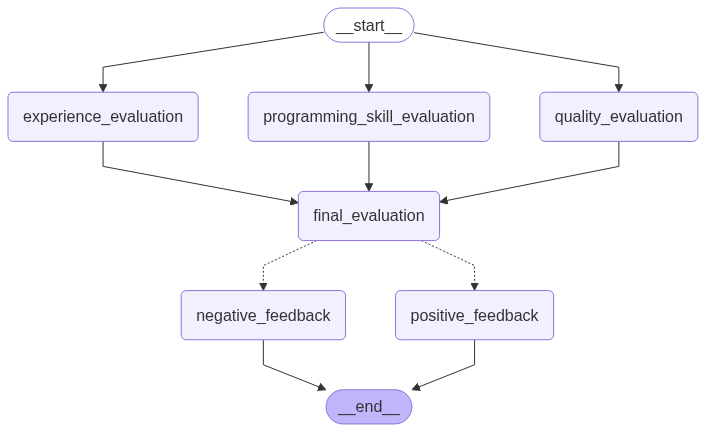

In [62]:
workflow

In [68]:
initial_state = {
    'resume':resume,
}

result = workflow.invoke(initial_state)

result

feedback="The candidate demonstrates a strong grasp of various programming languages including C#, Python, JavaScript, and TypeScript. They have hands-on experience with modern web frameworks such as .NET 8, Blazor, React, Angular, and Vue.js, along with backend technologies like Node.js and Django. The candidate's experience with Oracle DB and other databases (MySQL, MongoDB) is also notable. Their familiarity with version control (Git, Azure DevOps) and CI/CD practices further strengthens their profile. The project experience, particularly in the fintech and banking sectors, showcases their ability to apply these skills in real-world scenarios. Overall, a solid skill set for a senior software engineer role." score=8


{'resume': '\nMOSTAFA RAYHAN\nSoftware Engineer\nWeb Developer with 3+ years of experience in designing and developing user interfaces, testing, and, debugging.\nProven ability in optimizing web functionalities that improve data retrieval and workflow efficiencies.\nFiNTECH HUB Ltd (Development Engineering)\nMirpur 10, Dhaka, Bangladesh | July 2024 - Present\nWorking on a General Banking Solution, Core Banking Solution,\nSecurity Module, and Administration Module using ASP.NET 8,\nBLAZOR, and Oracle DB (Store Procedure).\nCollaborate with cross-functional teams to implement solutions\nCollaborated on full-stack development for the solutions\nOptimize application architecture for improved performance,\nintegrating new technologies and best practices\nEngaged actively in sprint planning, backlog grooming, and daily\nstand-up meetings to ensure smooth project execution and\nteam alignment.\nLEADS Corporation Limited (Banking Solutions)\nMirpur 14, Dhaka, Bangladesh | April 2024 - June 202